## TP3 -Classification

In [55]:
import pandas as pd
import glob
import ta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score,f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import shap
import os
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt


## 1.1 Préparation du dataset

### 1.1.1 Création des labels

In [29]:
#1. Chargement des données
def chargement_des_donnees(filepaths):
    df = pd.read_csv(filepaths, usecols=['Close'])
    return df

In [30]:
#2. Création colonne "Close_horizon"
def colonne_horizon(df, jours=20):
    df['Close_horizon'] = df['Close'].shift(-jours)
    return df

In [31]:
#3. Creation colonne 'Horizon_return' -->rendement sur 20 jours:
def colonne_horizon_return(df):
    df['Horizon_return'] = df['Close_horizon'] / df['Close']-1
    return df

In [32]:
#4. Création colonne "Label":
def colonne_label(df):
    if df['Horizon_return'] > 0.05:
        df['Label'] = 2
    elif df['Horizon_return'] < -0.05:
        df['Label'] = 0
    else:
        df['Label'] = 1
    return df

#### 1.1.2 Conversion des données pour un problème de classification classique

In [33]:
def features_ta(df,close_col='Close'):
    
    close = df[close_col]
 
    # Moyennes mobiles
    df["SMA 20"] = ta.trend.SMAIndicator(close=close, window=20).sma_indicator()
    df["EMA 20"] = ta.trend.EMAIndicator(close=close, window=20).ema_indicator()
 
    # Momentum
    df["RSI 14"] = ta.momentum.RSIIndicator(close=close, window=14).rsi()
 
    macd = ta.trend.MACD(close=close)
    df["MACD"]        = macd.macd()
    df["MACD Signal"] = macd.macd_signal()
 
    #  Volatilité
    bb = ta.volatility.BollingerBands(close=close, window=20, window_dev=2)
    df["Bollinger High"] = bb.bollinger_hband()
    df["Bollinger Low"]  = bb.bollinger_lband()
 
    df["Rolling Volatility 20"] = df[close_col].pct_change().rolling(window=20).std()
 
    df["ROC 10"] = ta.momentum.ROCIndicator(close=close, window=10).roc()
 
    return df

In [34]:
filepaths=glob.glob("/Users/chloe/Documents/M2/S4/Data Science/Cours 1/Companies_historical_data/*.csv")

In [35]:
entreprises = {}
for filepath in filepaths:
    nom = os.path.basename(filepath).replace('.csv', '')
    df = chargement_des_donnees(filepath)
    df=colonne_horizon(df)
    df=colonne_horizon_return(df)
    df=df.apply(colonne_label, axis=1) #met un peu de temps 
    df=df.dropna() #on supprime les lignes vides
    df=features_ta(df,close_col='Close')
    df=df.dropna() #on supprime les lignes vides après le calcul des features techniques
    entreprises[nom] = df

#### 1.1.3 Processing des datasets obtenus pour le pipeline de classification

In [37]:
#1.Concatenation de l'ensemble des dataframes
def concatenation(data):
    data_concat=pd.concat(data.values(), ignore_index=True)
    return data_concat

In [38]:
data=concatenation(entreprises)

In [39]:
#2. Séparation des features et de la target
def separation_features_target(df):
    X=df.drop(columns=['Label','Close_horizon','Horizon_return'])
    y=df['Label']
    return X, y

In [40]:
X,y=separation_features_target(data)
features_names=X.columns.tolist() #on en a besoin pour plus tard

In [41]:
#3. Standardiser les données de X
def standardisation(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled,scaler

In [42]:
X_scaled,scaler=standardisation(X)

In [43]:
#4. Utiliser train_test_split pour créer les datasets d'entraînement et de test
def split_train_test(X, y, test_size=0.2, random_state=42, shuffle=False):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state,shuffle=shuffle)
    return X_train, X_test, y_train, y_test

In [44]:
X_train, X_test, y_train, y_test = split_train_test(X_scaled, y)

### 1.2 Algorithme de classification

A partir de là c'est à revoir 

In [ ]:
#1. Effectuer un gridsearch pour chaque algorithme

#pour eviter d'attendre trop longtemps, on a choisi des hyperparametres limités pour chaque algorithme.
# ameliorer cette partie plus tard 

tscv = TimeSeriesSplit(n_splits=5) #respecte l'ordre temporel des données
def gridsearch_Xgboost(X_train, y_train):
    param_grid_xgb = {
        'n_estimators': [50, 100],
        'max_depth': [3, 6],
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8]
    }
    grid_xgb = GridSearchCV(estimator=XGBClassifier(random_state=42), param_grid=param_grid_xgb, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    grid_xgb.fit(X_train, y_train)
    return grid_xgb.best_estimator_


In [46]:
def gridsearch_Random_forest(X_train, y_train):
    param_grid_rf = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'max_features': ['sqrt']
    }
    grid_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid_rf, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    return grid_rf.best_estimator_

In [47]:
def gridsearch_KNN(X_train, y_train):
    param_grid_knn = {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
    grid_knn = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid_knn, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    grid_knn.fit(X_train, y_train)
    return grid_knn.best_estimator_

In [48]:
def gridsearch_regression_logistique(X_train, y_train):
    param_grid_lr = {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    }
    grid_lr = GridSearchCV(estimator=LogisticRegression(random_state=42), param_grid=param_grid_lr, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    grid_lr.fit(X_train, y_train)
    return grid_lr.best_estimator_

In [49]:
def gridsearch_SVM(X_train, y_train):
    param_grid_svm = {
        'C': [1, 10],
        'kernel': [ 'rbf'],
        'gamma': ['scale']
    }
    grid_svm = GridSearchCV(estimator=SVC(random_state=42), param_grid=param_grid_svm, cv=tscv, scoring='f1_weighted', n_jobs=-1)
    grid_svm.fit(X_train, y_train)
    return grid_svm.best_estimator_

In [50]:
#2. Appliquer le meilleur moèle
modeles = {
    'XGBoost': gridsearch_Xgboost(X_train, y_train),
    'Random Forest': gridsearch_Random_forest(X_train, y_train),
    'KNN': gridsearch_KNN(X_train, y_train),
    'Logistic Regression': gridsearch_regression_logistique(X_train, y_train),
    'SVM': gridsearch_SVM(X_train[:5000], y_train[:5000]) #on limite le nombre de données pour le SVM pour éviter un temps d'attente trop long
}

In [51]:
#fonction de prédiction
def prediction(model, X_test):
    return model.predict(X_test)
   

In [ ]:
#3. Affichage des résultats grâce à classification_report

def afficher_resultats(modeles, X_test, y_test):
    noms_classes = ['Sell (0)', 'Hold (1)', 'Buy (2)']
    for nom, model in modeles.items():
        print("\n" + "="*40)
        print(f" RÉSULTATS : {nom} ")
        print("="*40)
        y_pred = prediction(model, X_test)
        print(classification_report(y_test, y_pred, target_names=noms_classes, zero_division=0))

afficher_resultats(modeles, X_test, y_test)


 RÉSULTATS : XGBoost 
              precision    recall  f1-score   support

    Sell (0)       0.26      0.05      0.09      2116
    Hold (1)       0.48      0.82      0.60      4458
     Buy (2)       0.40      0.23      0.29      3303

    accuracy                           0.45      9877
   macro avg       0.38      0.36      0.33      9877
weighted avg       0.41      0.45      0.39      9877


 RÉSULTATS : Random Forest 
              precision    recall  f1-score   support

    Sell (0)       0.31      0.10      0.15      2116
    Hold (1)       0.49      0.79      0.60      4458
     Buy (2)       0.41      0.24      0.30      3303

    accuracy                           0.46      9877
   macro avg       0.40      0.38      0.35      9877
weighted avg       0.42      0.46      0.41      9877


 RÉSULTATS : KNN 
              precision    recall  f1-score   support

    Sell (0)       0.26      0.22      0.24      2116
    Hold (1)       0.48      0.61      0.54      4458
    

In [ ]:
#sauvegarder la version finale des resultats
def sauvegarder_resultats(modeles, X_test, y_test, features_names):
    noms_classes = ['Sell (0)', 'Hold (1)', 'Buy (2)']
    os.makedirs("resultats", exist_ok=True)

    for nom, model in modeles.items():
        y_pred = model.predict(X_test)
        rapport = classification_report(y_test, y_pred,
                                        target_names=noms_classes,
                                        zero_division=0)
        # Sauvegarde dans un fichier
        with open(f"resultats/{nom.replace(' ', '_')}.txt", "w") as f:
            f.write(f"RÉSULTATS : {nom}\n")
            f.write("="*40 + "\n")
            f.write(rapport)

sauvegarder_resultats(modeles, X_test, y_test, features_names)


--- Analyse SHAP : XGBoost ---


/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_9753/1823674839.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


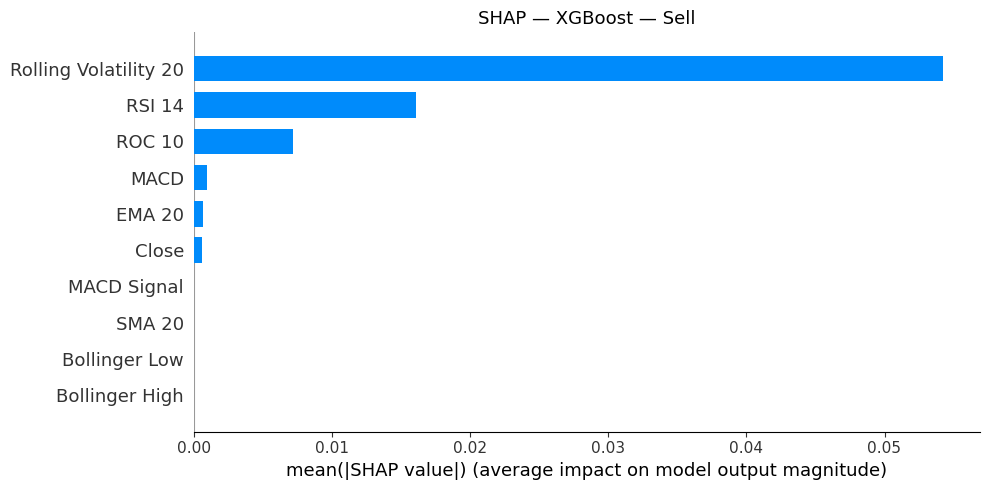

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_9753/1823674839.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


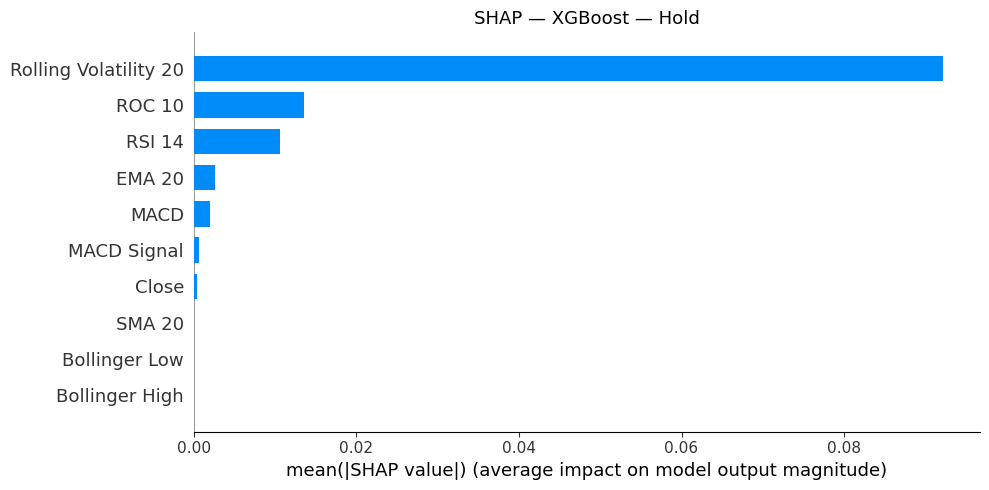

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_9753/1823674839.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


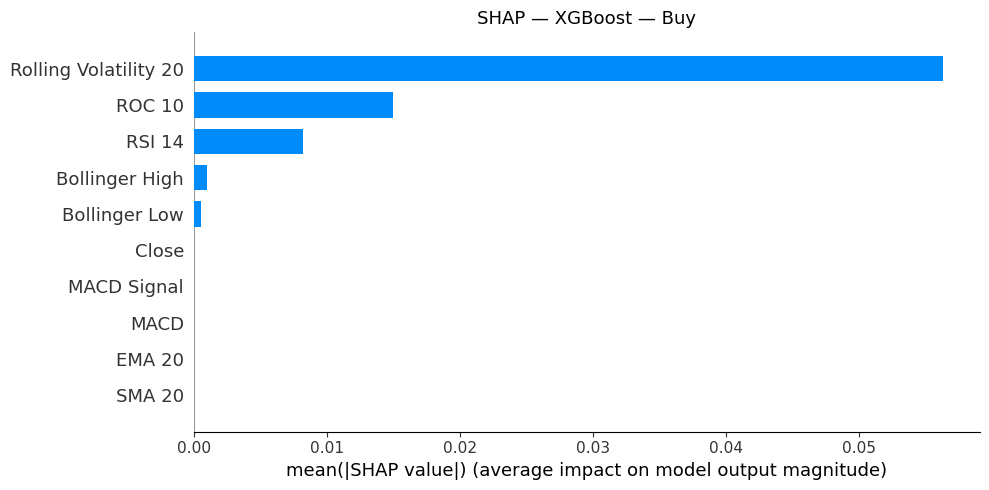


--- Analyse SHAP : Random Forest ---


/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_9753/1823674839.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


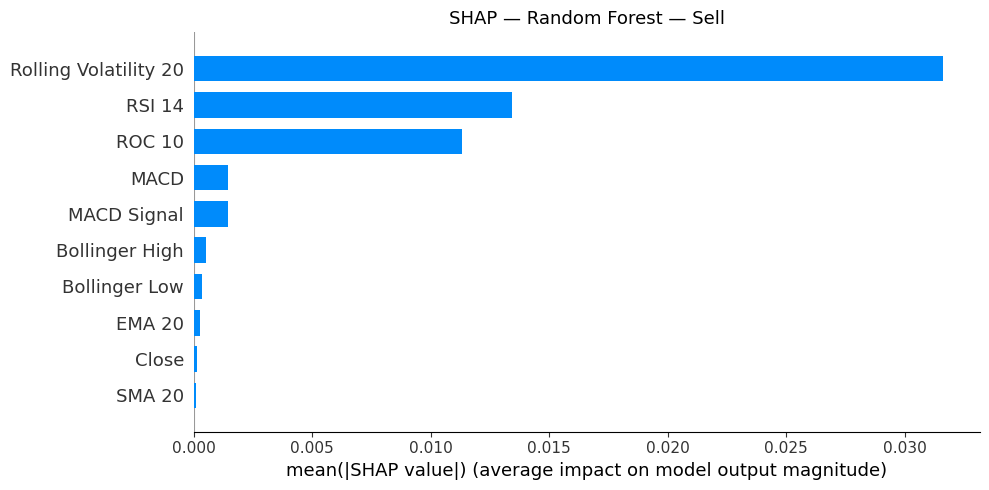

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_9753/1823674839.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


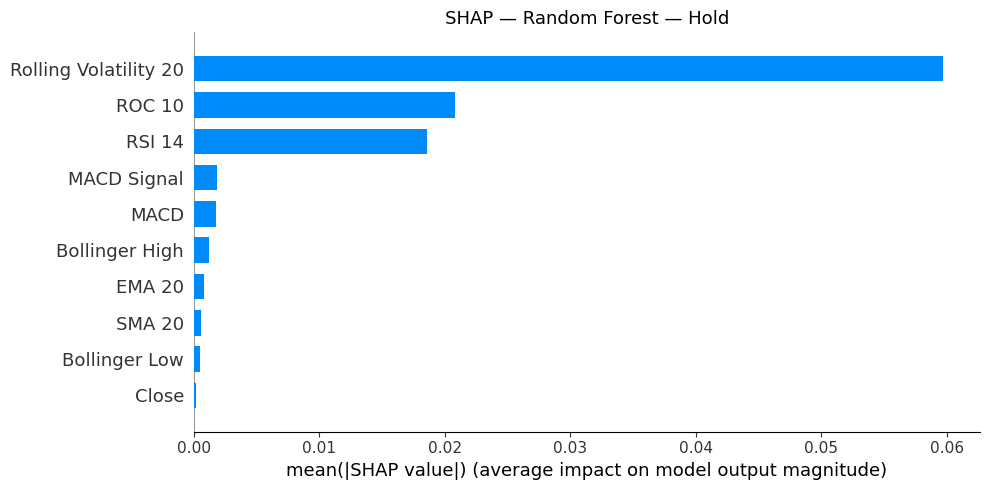

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_9753/1823674839.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


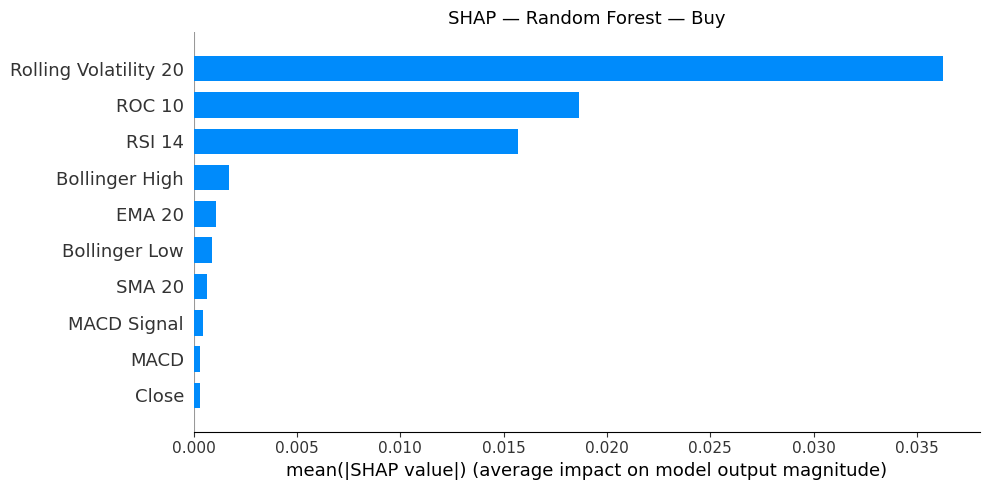

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_9753/1823674839.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



--- Analyse SHAP : KNN ---
  ⚠ Saut de KNN : incompatible avec SHAP.

--- Analyse SHAP : Logistic Regression ---


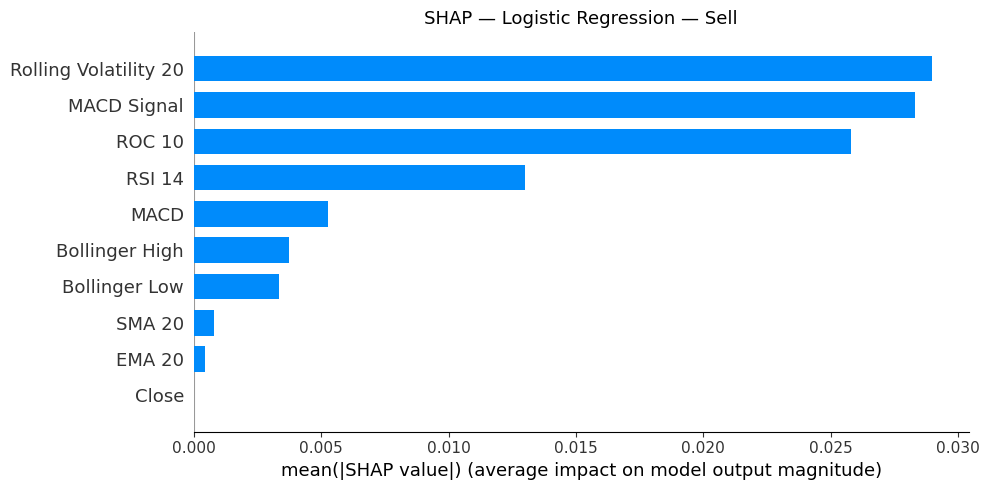

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_9753/1823674839.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


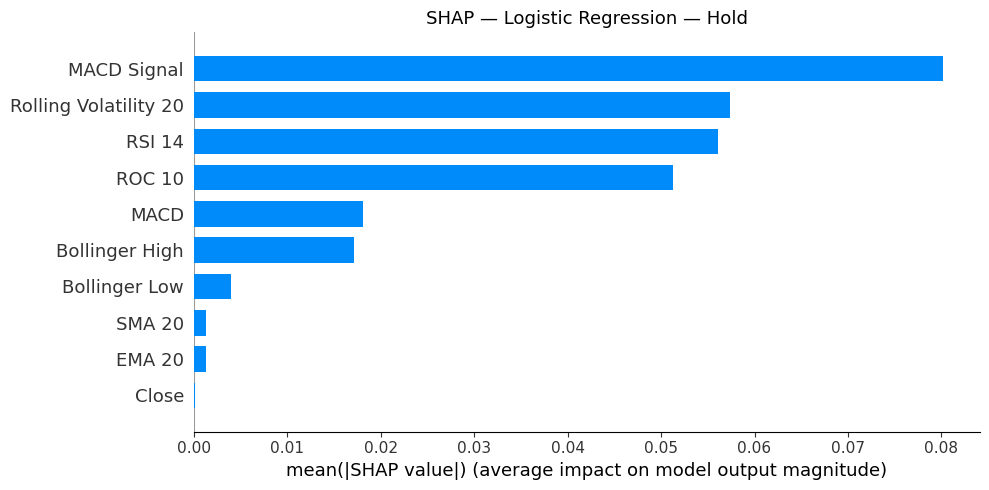

/var/folders/kv/z9rfv7l5235gnfj9wprx9_hm0000gn/T/ipykernel_9753/1823674839.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


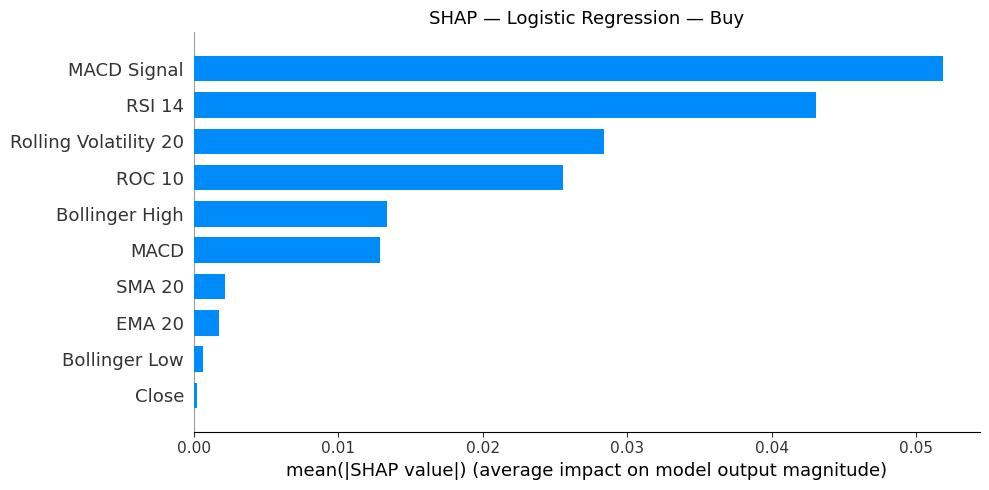


--- Analyse SHAP : SVM ---
  ⚠ Saut de SVM : incompatible avec SHAP.


In [ ]:
#4. Appliquer les shap.summary plot 

def get_explainer(nom, modele, X_train_df):
    if any(k in nom for k in ["XGBoost", "Random Forest"]):
        return shap.TreeExplainer(modele)
    elif "Logistic Regression" in nom:
        return shap.LinearExplainer(modele, X_train_df)
    else:
        return None  # SVM et KNN ignorés

def analyser_shap(modeles, X_train, X_test, feature_names):
    import numpy as np
    X_train_df    = pd.DataFrame(X_train, columns=feature_names)
    X_test_df     = pd.DataFrame(X_test,  columns=feature_names)
    n_sample      = min(max(int(len(X_test_df) * 0.1), 50), 200)
    X_test_sample = X_test_df.iloc[:n_sample]
    class_names   = {0: "Sell", 1: "Hold", 2: "Buy"}

    for nom, modele in modeles.items():
        print(f"\n--- Analyse SHAP : {nom} ---")
        explainer = get_explainer(nom, modele, X_train_df)
        if explainer is None:
            print(f"  Saut de {nom} : incompatible avec SHAP.")
            continue

        shap_values = explainer.shap_values(X_test_sample)
        if isinstance(shap_values, list):
            shap_values = np.stack(shap_values, axis=-1)

        for class_idx, class_name in class_names.items():
            sv = shap_values[..., class_idx] if shap_values.ndim == 3 else shap_values
            shap.summary_plot(sv, X_test_sample, plot_type="bar", show=False, plot_size=(10, 5))
            plt.title(f"SHAP — {nom} — {class_name}", fontsize=13)
            plt.tight_layout()
            plt.show()
            plt.close()

analyser_shap(modeles, X_train, X_test, features_names)


In [ ]:
#Tableau comparatif des résultats  
def tableau_comparatif(modeles, X_test, y_test):
    resultats = []
    for nom, model in modeles.items():
        y_pred = prediction(model, X_test)   # ← recalculé à chaque itération
        resultats.append({
            "Modèle"            : nom,
            "Accuracy"          : accuracy_score(y_test, y_pred),
            "Precision (Macro)" : precision_score(y_test, y_pred, average='macro', zero_division=0),
            "Recall (Macro)"    : recall_score(y_test, y_pred, average='macro', zero_division=0),
            "F1-Score (Macro)"  : f1_score(y_test, y_pred, average='macro', zero_division=0)
        })
    df_resultats = pd.DataFrame(resultats).sort_values(by="F1-Score (Macro)", ascending=False)
    return df_resultats

df_comparatif = tableau_comparatif(modeles, X_test, y_test)
print(df_comparatif)

                Modèle  Accuracy  Precision (Macro)  Recall (Macro)  \
2                  KNN  0.412372           0.369112        0.366142   
1        Random Forest  0.459856           0.401487        0.378220   
4                  SVM  0.433937           0.382055        0.370464   
0              XGBoost  0.454996           0.378561        0.364882   
3  Logistic Regression  0.459654           0.326386        0.343883   

   F1-Score (Macro)  
2          0.361749  
1          0.353353  
4          0.349473  
0          0.327110  
3          0.239043  


### 1.3 Proposition d'améliorations

A faire